In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
subcompartments = pd.read_csv("../data/subcompartments/rao2014_subcompartments/subcompartment_with_histone_and_tf_features.csv")
print(subcompartments.head())

  chrom    start      end subcompartment  score strand  thickStart  thickEnd  \
0  chr1   764620  1968561             A1      2      .      764620   1968561   
1  chr1  1968561  2168561             B1     -1      .     1968561   2168561   
2  chr1  2168561  2368561             A1      2      .     2168561   2368561   
3  chr1  2368561  2468561             B1     -1      .     2368561   2468561   
4  chr1  2468561  2568561             A1      2      .     2468561   2568561   

     itemRgb  chrom_num  ...  RELB  ELK1  IRF4  CBX5  MLLT1  ZNF24  ZBTB40  \
0  34,139,34          1  ...    64    19    13     3     76     12      23   
1  220,20,60          1  ...     0     0     0     0      0      0       0   
2  34,139,34          1  ...     4     2     3     2     10      0       4   
3  220,20,60          1  ...     3     3     0     0      0      0       2   
4  34,139,34          1  ...     9     2     3     0      9      1       1   

   SMC3  SMARCA5  STAT3  
0    30       50      2 

### Check compartment blocks

In [42]:
original_subcompartments = pd.read_csv("./data/subcompartments/rao2014_subcompartments/GSE63525_GM12878_subcompartments.bed", sep="\t", header=None)
# drop columns 4,5,6,7,8
original_subcompartments = original_subcompartments.drop(columns=[4, 5, 6, 7, 8])
# rename columns
original_subcompartments.columns = ["chrom", "start", "end", "subcompartment"]
original_subcompartments = original_subcompartments.sort_values(['chrom', 'start'])
# drop rows with subcompartment nan
original_subcompartments = original_subcompartments.dropna(subset=['subcompartment'])


In [58]:
print(original_subcompartments.head(30))

    chrom     start       end subcompartment
117  chr1    700000   1900000             A1
118  chr1   1900000   2100000             B1
119  chr1   2100000   2300000             A1
120  chr1   2300000   2400000             B1
121  chr1   2400000   2500000             A1
122  chr1   2500000   2600000             B1
124  chr1   2700000   3500000             B1
125  chr1   3500000   3800000             A1
126  chr1   3800000   3900000             B1
128  chr1   4000000   6000000             B1
129  chr1   6000000   6100000             A1
130  chr1   6100000   6200000             B1
131  chr1   6200000   7000000             A1
132  chr1   7000000   7800000             B1
133  chr1   7800000  12600000             A1
134  chr1  12600000  13000000             B1
136  chr1  13100000  13200000             B1
138  chr1  13700000  14000000             B1
139  chr1  14000000  14100000             A1
140  chr1  14100000  15400000             B1
141  chr1  15400000  17100000             A1
143  chr1 

In [55]:
sniper_subcompartments = pd.read_csv("./data/subcompartments/sniper_subcompartments/GM12878_track_hg38.bed.txt", sep="\t")

In [59]:
print(sniper_subcompartments.head(30))

   chrom    start      end subcompartment
0   chr1   664620   764620             B1
1   chr1   764620   864620             A1
2   chr1   864620   964620             A1
3   chr1   964620  1064620             A1
4   chr1  1064620  1164620             A1
5   chr1  1164620  1264620             A1
6   chr1  1264620  1364620             A1
7   chr1  1364620  1464620             A1
8   chr1  1464620  1564620             A1
9   chr1  1564620  1668561             A1
10  chr1  1668561  1768561             A1
11  chr1  1768561  1868561             A1
12  chr1  1868561  1968561             A1
13  chr1  1968561  2068561             B1
14  chr1  2068561  2168561             B1
15  chr1  2168561  2268561             A1
16  chr1  2268561  2368561             B1
17  chr1  2368561  2468561             B1
18  chr1  2468561  2568561             B1
19  chr1  2568561  2668561             B1
20  chr1  2783455  2883435             B1
21  chr1  2883435  2983436             B1
22  chr1  2983436  3083436        

In [47]:
def analyze_compartment_blocks(data_frame, subcompartment_column='subcompartment'):
    """
    Analyze block sizes of subcompartments and compartments.
    
    Parameters:
    -----------
    data_frame : pandas DataFrame
        DataFrame containing chromosome and subcompartment labels.
        Should have at least 'chrom' and subcompartment_column columns.
    subcompartment_column : str, default='subcompartment'
        Column name containing the subcompartment labels.
        
    Returns:
    --------
    subc_df : pandas DataFrame
        DataFrame of subcompartment block statistics per chromosome
    comp_df : pandas DataFrame
        DataFrame of compartment block statistics per chromosome
    ordered_chroms : list
        List of chromosomes ordered naturally
    """
    import numpy as np
    import pandas as pd
    from natsort import natsorted
    
    # Define helper functions
    def compute_block_sizes(labels):
        block_sizes = []
        if not labels:
            return block_sizes
        last_label = labels[0]
        count = 1
        for l in labels[1:]:
            if l == last_label:
                count += 1
            else:
                block_sizes.append(count)
                last_label = l
                count = 1
        block_sizes.append(count)
        return block_sizes

    def subc_to_compartment(labels):
        return ['A' if l.startswith('A') else 'B' if l.startswith('B') else 'NA' for l in labels]

    # To store stats
    subc_stats = {}
    comp_stats = {}

    for chrom, group in data_frame.groupby('chrom'):
        valid = group[subcompartment_column].notna()
        lbls = group.loc[valid, subcompartment_column].astype(str).tolist()
        if not lbls:
            continue
        subc_blocks = compute_block_sizes(lbls)
        comp_lbls = subc_to_compartment(lbls)
        ab_lbls = [l for l in comp_lbls if l in ('A', 'B')]
        comp_blocks = compute_block_sizes(ab_lbls)

        # Save stats in dictionaries
        subc_stats[chrom] = {
            'median': np.median(subc_blocks), 
            'mean': np.mean(subc_blocks),
            'n_blocks': len(subc_blocks)
        }
        comp_stats[chrom] = {
            'median': np.median(comp_blocks), 
            'mean': np.mean(comp_blocks),
            'n_blocks': len(comp_blocks)
        }

    # Make DataFrames for nice display
    subc_df = pd.DataFrame(subc_stats).T
    comp_df = pd.DataFrame(comp_stats).T
    ordered_chroms = natsorted(subc_df.index)
    
    return subc_df, comp_df, ordered_chroms

Subcompartment block sizes per chromosome:
       median      mean  n_blocks
chr1      1.0  1.049180     305.0
chr2      1.0  1.025078     319.0
chr3      1.0  1.003922     255.0
chr4      1.0  1.022624     221.0
chr5      1.0  1.038023     263.0
chr6      1.0  1.031250     192.0
chr7      1.0  1.049751     201.0
chr8      1.0  1.017442     172.0
chr9      1.0  1.018868     212.0
chr10     1.0  1.045685     197.0
chr11     1.0  1.025510     196.0
chr12     1.0  1.021505     186.0
chr13     1.0  1.018868     159.0
chr14     1.0  1.020000     150.0
chr15     1.0  1.036765     136.0
chr16     1.0  1.142857     105.0
chr17     1.0  1.085366      82.0
chr18     1.0  1.034483     116.0
chr19     1.0  1.093750      96.0
chr20     1.0  1.036585      82.0
chr21     1.0  1.054054      37.0
chr22     1.0  1.090909      33.0

Compartment block sizes per chromosome:
       median      mean  n_blocks
chr1      1.0  1.226054     261.0
chr2      1.0  1.397436     234.0
chr3      1.0  1.168950     219.

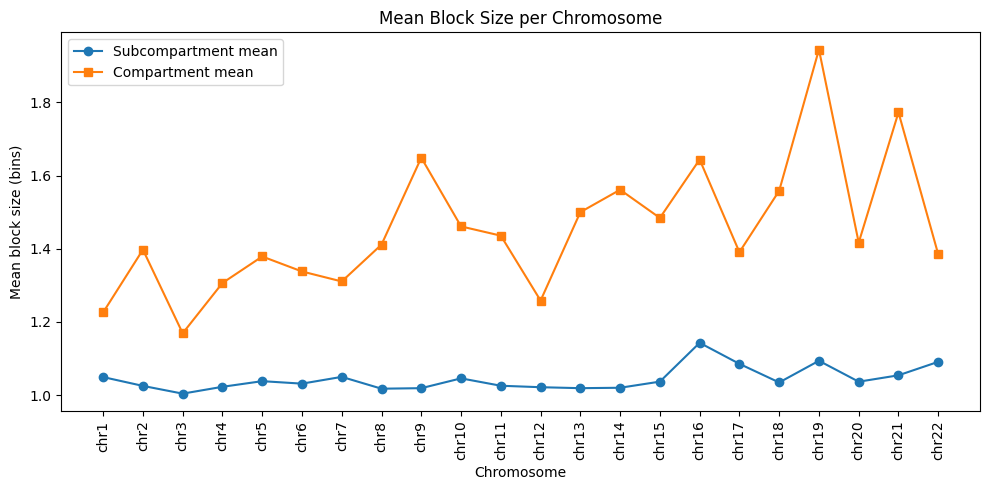

In [48]:
# Example usage
subc_df, comp_df, ordered_chroms = analyze_compartment_blocks(original_subcompartments)

print("Subcompartment block sizes per chromosome:")
print(subc_df.loc[ordered_chroms])

print("\nCompartment block sizes per chromosome:")
print(comp_df.loc[ordered_chroms])

# Optional: Create a plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ordered_chroms, subc_df.loc[ordered_chroms, 'mean'], marker='o', label='Subcompartment mean')
plt.plot(ordered_chroms, comp_df.loc[ordered_chroms, 'mean'], marker='s', label='Compartment mean')
plt.ylabel("Mean block size (bins)")
plt.xlabel("Chromosome")
plt.xticks(rotation=90)
plt.title("Mean Block Size per Chromosome")
plt.legend()
plt.tight_layout()
plt.show()

Subcompartment block sizes per chromosome:
       median      mean  n_blocks
chr1      2.0  5.280193     414.0
chr2      2.0  5.627685     419.0
chr3      3.0  6.498328     299.0
chr4      3.0  6.328814     295.0
chr5      2.0  4.991549     355.0
chr6      2.5  6.543307     254.0
chr7      2.0  5.662963     270.0
chr8      2.0  5.509728     257.0
chr9      2.0  4.046763     278.0
chr10     2.0  4.136364     308.0
chr11     2.0  4.538462     286.0
chr12     2.0  4.534965     286.0
chr13     2.0  4.896907     194.0
chr14     2.0  3.834061     229.0
chr15     2.0  4.919753     162.0
chr16     2.0  5.437500     144.0
chr17     2.0  8.180851      94.0
chr18     2.0  3.920635     189.0
chr19     2.0  6.494118      85.0
chr20     3.0  5.547170     106.0
chr21     4.0  7.860465      43.0
chr22     4.0  8.219512      41.0

Compartment block sizes per chromosome:
       median       mean  n_blocks
chr1      4.0   7.537931     290.0
chr2      3.0   9.585366     246.0
chr3      4.0   8.953917     

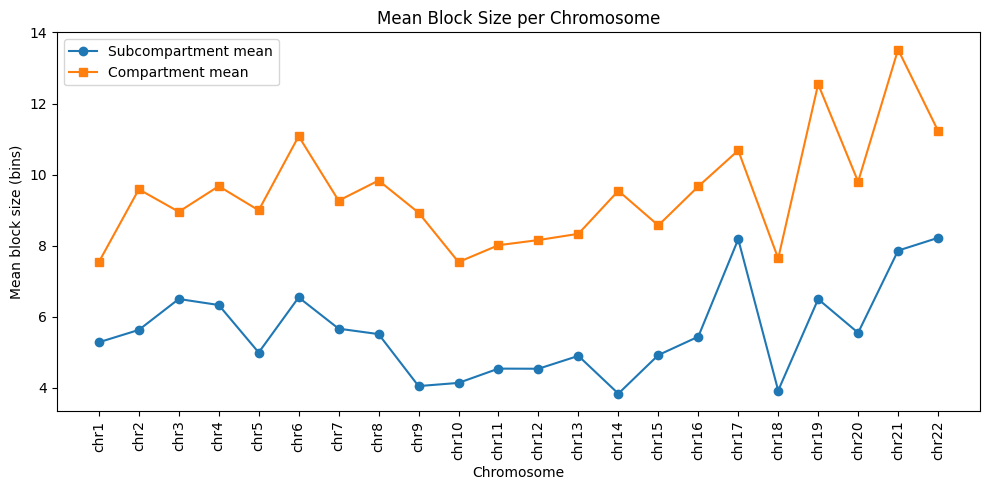

In [56]:
# Example usage
subc_df, comp_df, ordered_chroms = analyze_compartment_blocks(sniper_subcompartments)

print("Subcompartment block sizes per chromosome:")
print(subc_df.loc[ordered_chroms])

print("\nCompartment block sizes per chromosome:")
print(comp_df.loc[ordered_chroms])

# Optional: Create a plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ordered_chroms, subc_df.loc[ordered_chroms, 'mean'], marker='o', label='Subcompartment mean')
plt.plot(ordered_chroms, comp_df.loc[ordered_chroms, 'mean'], marker='s', label='Compartment mean')
plt.ylabel("Mean block size (bins)")
plt.xlabel("Chromosome")
plt.xticks(rotation=90)
plt.title("Mean Block Size per Chromosome")
plt.legend()
plt.tight_layout()
plt.show()

### Analyses

Feature columns: ['H3K27me3_x', 'H3K4me3_x', 'H3K36me3_x', 'H3K27ac', 'H3K79me2', 'H4K20me1', 'H3K4me2', 'H3K4me3_y', 'H3K4me1', 'H3K36me3_y', 'H2AFZ', 'H3K27me3_y', 'H3K4me3', 'H3K9ac', 'H3K9me3', 'ESRRA', 'BCLAF1', 'TARDBP', 'TCF3', 'MTA2', 'NRF1', 'BMI1', 'NFATC3', 'CEBPZ', 'ZBTB11', 'ELF1', 'YY1', 'ARID3A', 'ATF7', 'POLR2A', 'SUPT20H', 'GATAD2B', 'IRF3', 'CUX1', 'TRIM22', 'SP1', 'TAF1', 'MAX', 'HDAC6', 'NFIC', 'JUNB', 'MEF2A', 'PBX3', 'BATF', 'EBF1', 'RUNX3', 'TBL1XR1', 'RB1', 'RBBP5', 'NFATC1', 'CHD2', 'NBN', 'REST', 'SREBF2', 'SPI1', 'NKRF', 'RAD51', 'DPF2', 'MYB', 'BRCA1', 'ZNF207', 'SMAD1', 'USF2', 'RELA', 'NFYA', 'RAD21', 'NR2C2', 'KAT2A', 'MTA3', 'CREB1', 'ETS1', 'CBX3', 'GABPA', 'IKZF1', 'UBTF', 'ZBTB33', 'ZNF384', 'SRF', 'NFXL1', 'ARNT', 'HDAC2', 'CTCF', 'POU2F2', 'EP300', 'WRNIP1', 'MXI1', 'NFYB', 'POLR2AphosphoS5', 'BACH1', 'TBP', 'MAZ', 'LARP7', 'CHD1', 'ZNF217', 'HDGF', 'SIX5', 'KLF5', 'E2F8', 'MAFK', 'ETV6', 'SUZ12', 'ATF2', 'USF1', 'BHLHE40', 'EED', 'ZNF687', 'SMAD5',

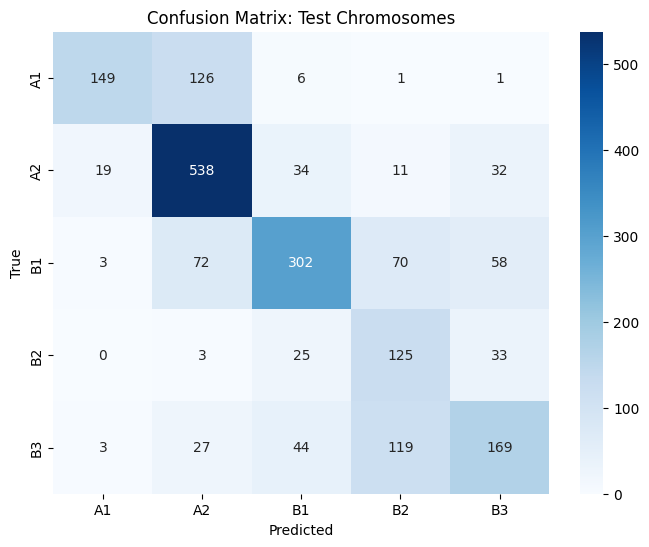

In [11]:
# 1. Identify features
non_feature_cols = [
    "chrom", "start", "end", "subcompartment", "score", "strand",
    "thickStart", "thickEnd", "itemRgb", "chrom_num"
]
feature_cols = [col for col in subcompartments.columns if col not in non_feature_cols]
print("Feature columns:", feature_cols)

# 2. Split train/test
train_chroms = [i for i in range(2, 24, 2)]
test_chroms = [i for i in range(1, 24, 2)]
train = subcompartments[subcompartments["chrom_num"].isin(train_chroms)].copy()
test = subcompartments[subcompartments["chrom_num"].isin(test_chroms)].copy()

print("Training bins:", train.shape)
print("Testing bins:", test.shape)

# 3. X and y
X_train = train[feature_cols].values
X_test = test[feature_cols].values
y_train = train["subcompartment"].replace({"B4": "B3"}).values
y_test = test["subcompartment"].replace({"B4": "B3"}).values

# 4. Model (rest as before)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}
rf = RandomForestClassifier(random_state=42, class_weight="balanced")
cv = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, scoring="accuracy")
cv.fit(X_train, y_train)
print("Best parameters:", cv.best_params_)

rf_best = cv.best_estimator_
y_pred = rf_best.predict(X_test)
print(classification_report(y_test, y_pred))

labels = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Test Chromosomes")
plt.show()


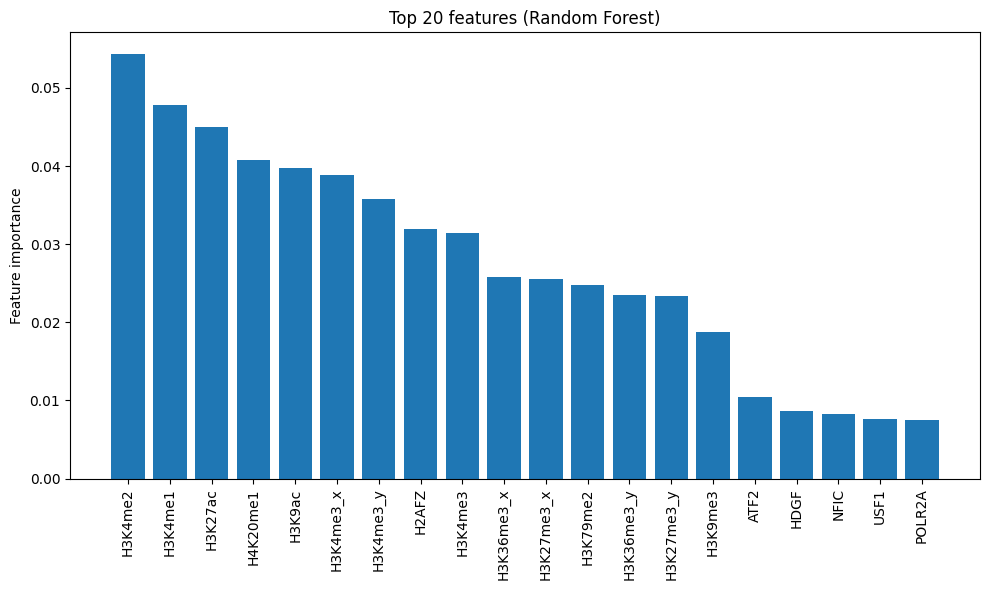

In [12]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_best.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_cols[i] for i in indices], rotation=90)
plt.ylabel("Feature importance")
plt.title("Top 20 features (Random Forest)")
plt.tight_layout()
plt.show()


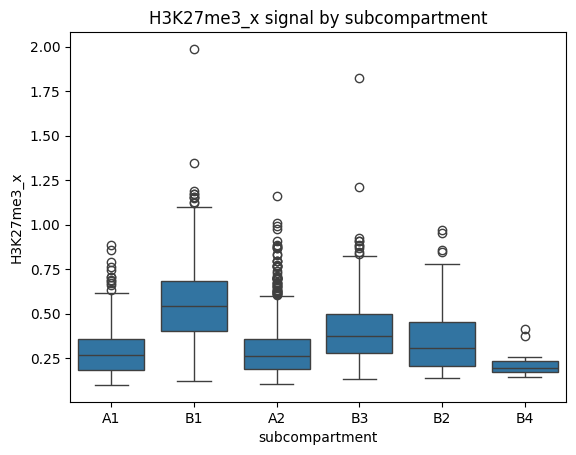

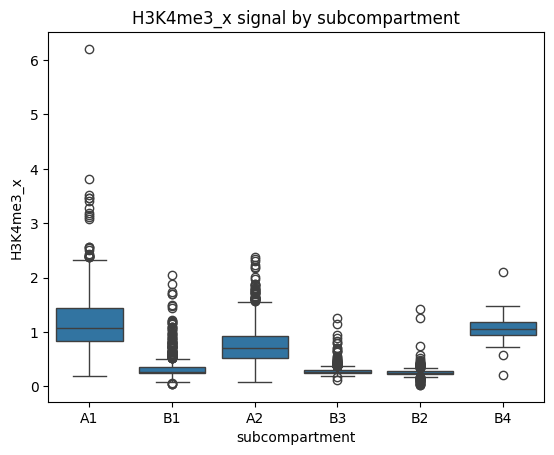

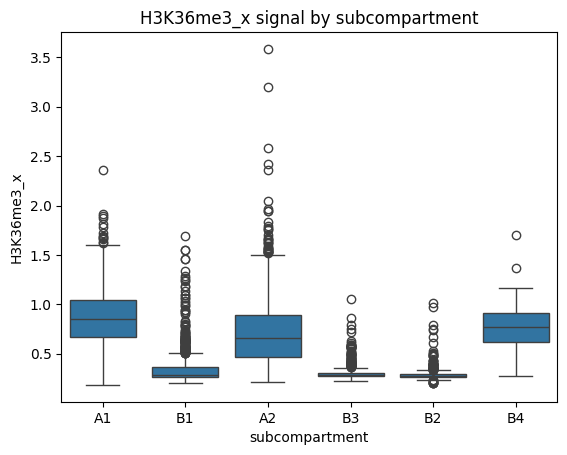

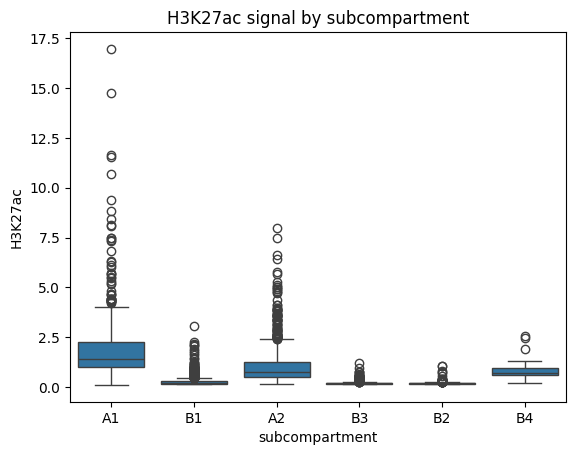

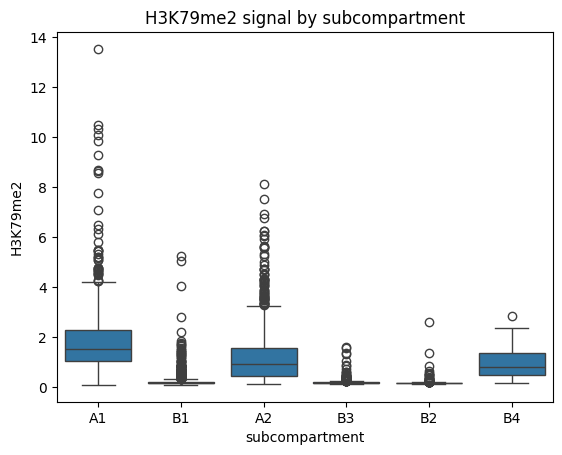

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

top_histones = [f for f in feature_cols if f.startswith("H3") or f.startswith("H4")][:5]  # top 5 for demo

for mark in top_histones:
    plt.figure()
    sns.boxplot(x=subcompartments["subcompartment"], y=subcompartments[mark])
    plt.title(f"{mark} signal by subcompartment")
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Data setup (replace with your real train/test splits and feature_cols) ----
# X_train, X_test, y_train, y_test, feature_cols, all_classes = ...

# 1. Feature Selection with RFECV
print("Running RFECV feature selection using Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
selector = RFECV(rf, step=1, cv=3, scoring='accuracy', n_jobs=-1)
selector.fit(X_train, y_train)
selected_features = [feature_cols[i] for i, x in enumerate(selector.support_) if x]
print(f"Optimal number of features: {selector.n_features_}")
print("Selected features:", selected_features[:15], "...")  # print only first 15 for brevity

# Transform data to selected features
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)




Running RFECV feature selection using Random Forest...
Optimal number of features: 132
Selected features: ['H3K27me3_x', 'H3K4me3_x', 'H3K36me3_x', 'H3K27ac', 'H3K79me2', 'H4K20me1', 'H3K4me2', 'H3K4me3_y', 'H3K4me1', 'H3K36me3_y', 'H2AFZ', 'H3K27me3_y', 'H3K4me3', 'H3K9ac', 'H3K9me3'] ...

--- Using All features ---

Training RandomForest...
RandomForest AUROC: 0.906

Training XGBoost...


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4], got ['A1' 'A2' 'B1' 'B2' 'B3']


--- Using All features ---

Training RandomForest...
Classification report:
              precision    recall  f1-score   support

          A1       0.86      0.53      0.65       283
          A2       0.70      0.85      0.77       634
          B1       0.73      0.60      0.66       505
          B2       0.38      0.67      0.49       186
          B3       0.58      0.47      0.52       362

    accuracy                           0.65      1970
   macro avg       0.65      0.62      0.62      1970
weighted avg       0.68      0.65      0.65      1970



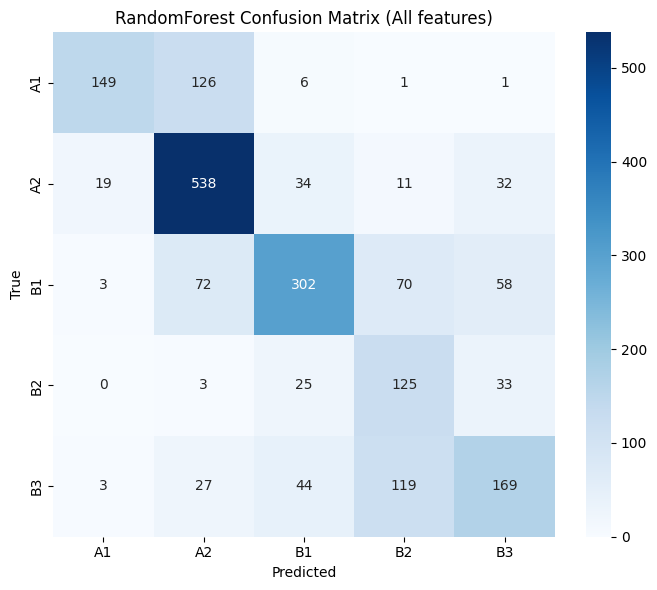


Training XGBoost...


d:\projects\UKY_Cheng\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [03:11:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

          A1       0.83      0.54      0.66       283
          A2       0.71      0.85      0.78       634
          B1       0.73      0.57      0.64       505
          B2       0.42      0.72      0.53       186
          B3       0.55      0.48      0.52       362

    accuracy                           0.65      1970
   macro avg       0.65      0.63      0.62      1970
weighted avg       0.68      0.65      0.65      1970



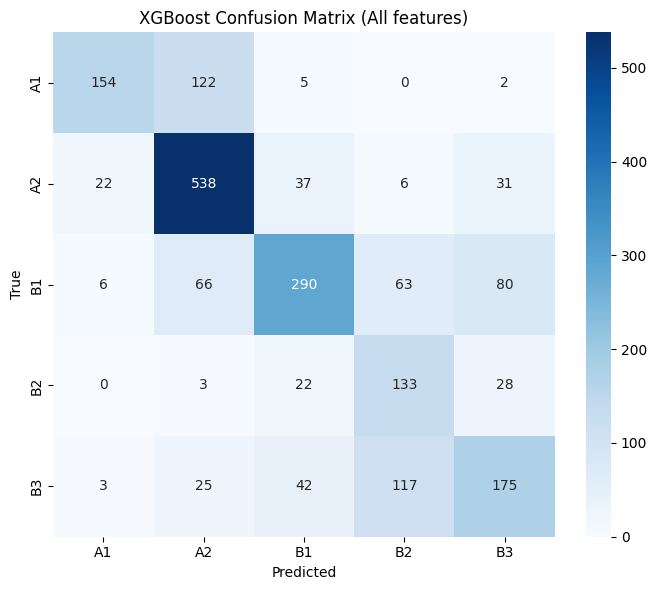


Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9174
[LightGBM] [Info] Number of data points in the train set: 1803, number of used features: 169
[LightGBM] [Info] Start training from score -2.184001
[LightGBM] [Info] Start training from score -1.095290
[LightGBM] [Info] Start training from score -1.602804
[LightGBM] [Info] Start training from score -1.806848
[LightGBM] [Info] Start training from score -1.674161
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

          A1       0.83      0.54      0.66       283
          A2       0.72      0.85      0.78       634
          B1       0.74      0.58      0.65       505
          B2       0.41      0.69      0.52       186
          B3       0.56      0.51      0.53       362

    accuracy                           0.66      1970
   macro avg       0.65      0.63      0.63      1970
weighted avg       0.68      0.66      0.66      1970



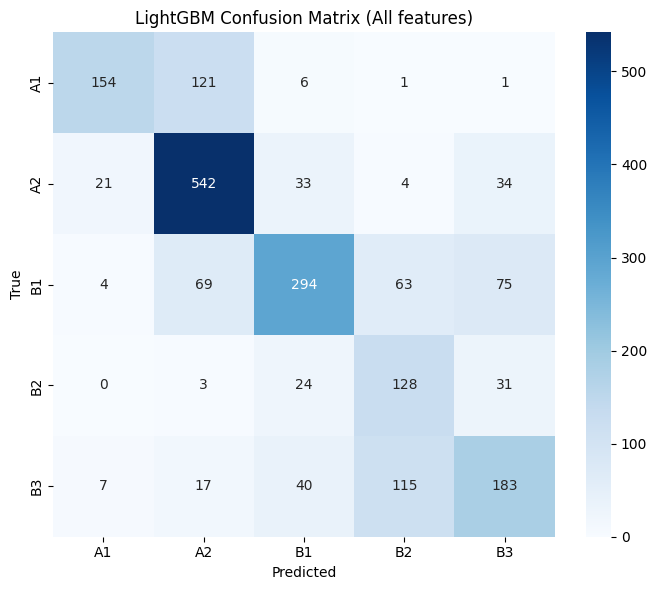


Training LogisticRegression...


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification report:
              precision    recall  f1-score   support

          A1       0.75      0.61      0.67       283
          A2       0.73      0.76      0.75       634
          B1       0.64      0.54      0.59       505
          B2       0.32      0.55      0.41       186
          B3       0.47      0.44      0.46       362

    accuracy                           0.61      1970
   macro avg       0.59      0.58      0.57      1970
weighted avg       0.63      0.61      0.61      1970



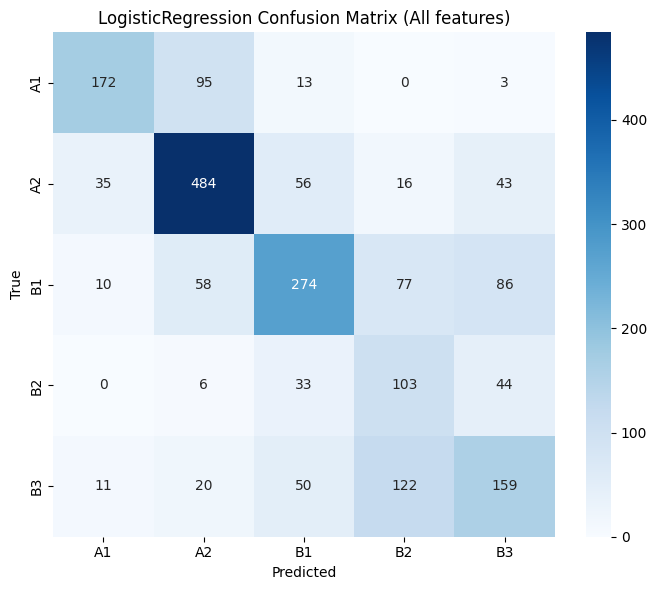


Training SVC...
Classification report:
              precision    recall  f1-score   support

          A1       0.84      0.34      0.48       283
          A2       0.63      0.75      0.69       634
          B1       0.45      0.84      0.58       505
          B2       0.23      0.02      0.03       186
          B3       0.76      0.30      0.43       362

    accuracy                           0.56      1970
   macro avg       0.58      0.45      0.44      1970
weighted avg       0.60      0.56      0.52      1970



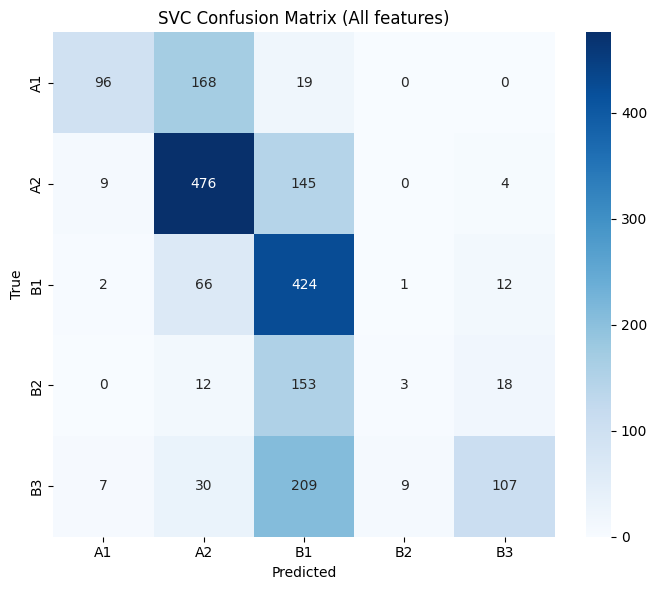


--- Using Selected features ---

Training RandomForest...
Classification report:
              precision    recall  f1-score   support

          A1       0.84      0.52      0.64       283
          A2       0.70      0.85      0.77       634
          B1       0.74      0.58      0.65       505
          B2       0.40      0.67      0.50       186
          B3       0.54      0.48      0.51       362

    accuracy                           0.65      1970
   macro avg       0.64      0.62      0.61      1970
weighted avg       0.67      0.65      0.65      1970



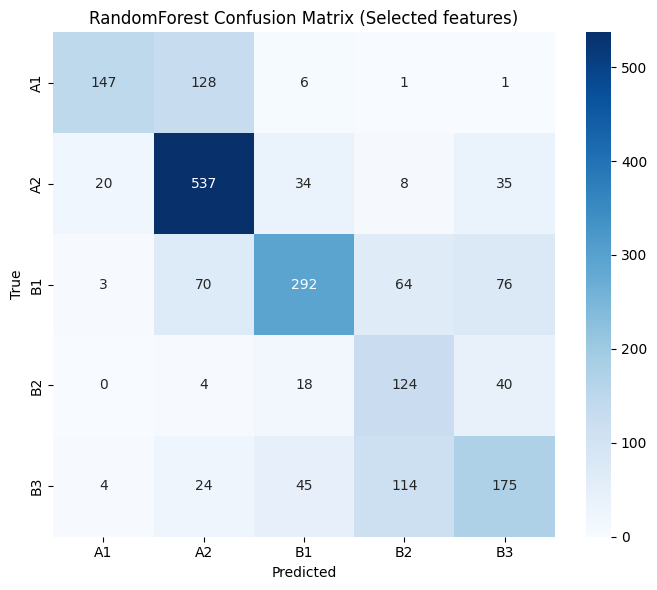


Training XGBoost...


d:\projects\UKY_Cheng\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [03:11:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report:
              precision    recall  f1-score   support

          A1       0.83      0.54      0.65       283
          A2       0.72      0.84      0.77       634
          B1       0.73      0.60      0.66       505
          B2       0.42      0.73      0.54       186
          B3       0.57      0.48      0.52       362

    accuracy                           0.66      1970
   macro avg       0.65      0.64      0.63      1970
weighted avg       0.68      0.66      0.66      1970



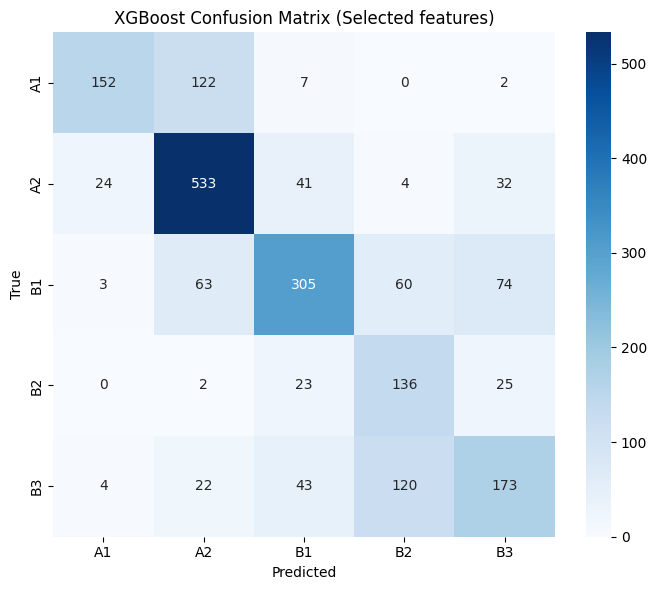


Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8737
[LightGBM] [Info] Number of data points in the train set: 1803, number of used features: 132
[LightGBM] [Info] Start training from score -2.184001
[LightGBM] [Info] Start training from score -1.095290
[LightGBM] [Info] Start training from score -1.602804
[LightGBM] [Info] Start training from score -1.806848
[LightGBM] [Info] Start training from score -1.674161
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification report:
              precision    recall  f1-score   support

          A1       0.84      0.54      0.66       283
          A2       0.73      0.85      0.78       634
          B1       0.74      0.61      0.67       505
          B2       0.43      0.70      0.53       186
          B3       0.57      0.51      0.54       362

    accuracy                           0.67      1970
   macro avg       0.66      0.64      0.64      1970
weighted avg       0.69      0.67      0.67      1970



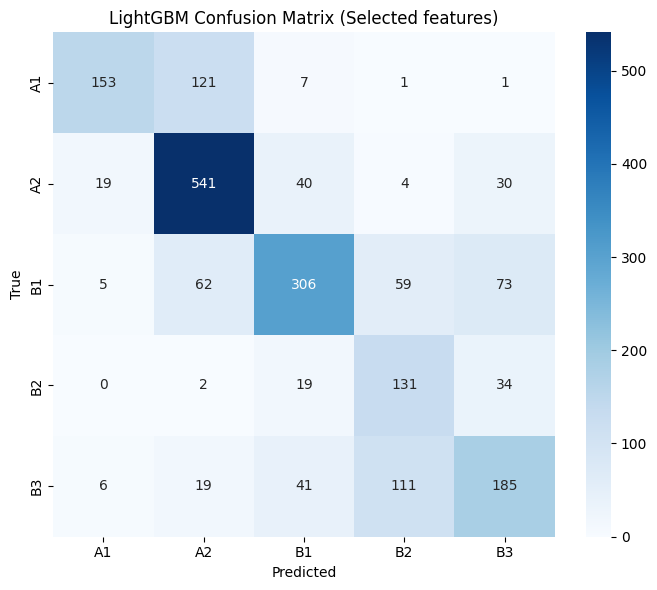


Training LogisticRegression...


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification report:
              precision    recall  f1-score   support

          A1       0.75      0.59      0.66       283
          A2       0.72      0.76      0.74       634
          B1       0.68      0.57      0.62       505
          B2       0.35      0.60      0.44       186
          B3       0.49      0.44      0.47       362

    accuracy                           0.61      1970
   macro avg       0.60      0.59      0.58      1970
weighted avg       0.64      0.61      0.62      1970



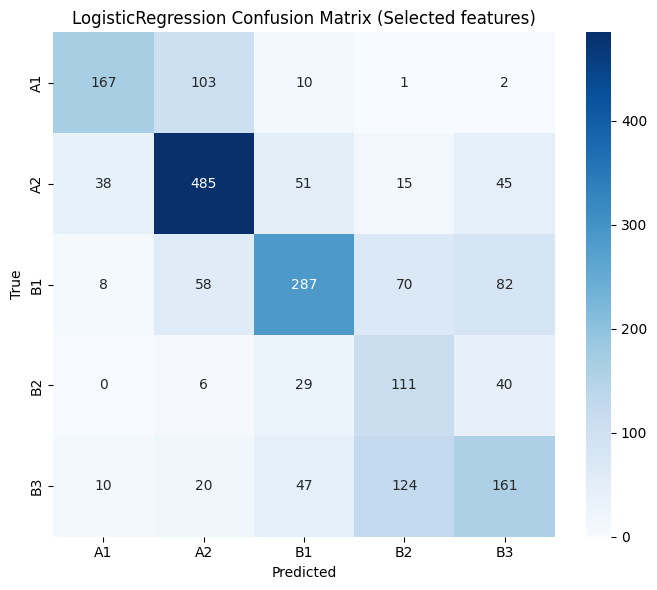


Training SVC...
Classification report:
              precision    recall  f1-score   support

          A1       0.85      0.35      0.49       283
          A2       0.63      0.75      0.69       634
          B1       0.45      0.84      0.58       505
          B2       0.23      0.02      0.03       186
          B3       0.76      0.30      0.43       362

    accuracy                           0.56      1970
   macro avg       0.59      0.45      0.44      1970
weighted avg       0.60      0.56      0.52      1970



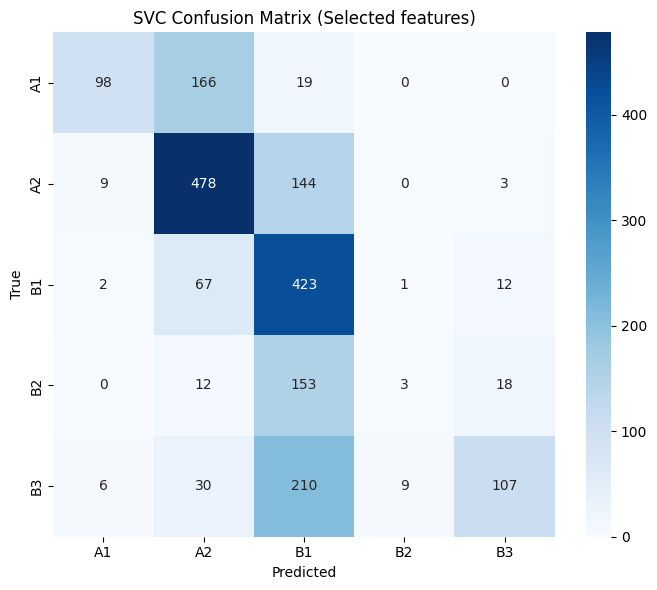

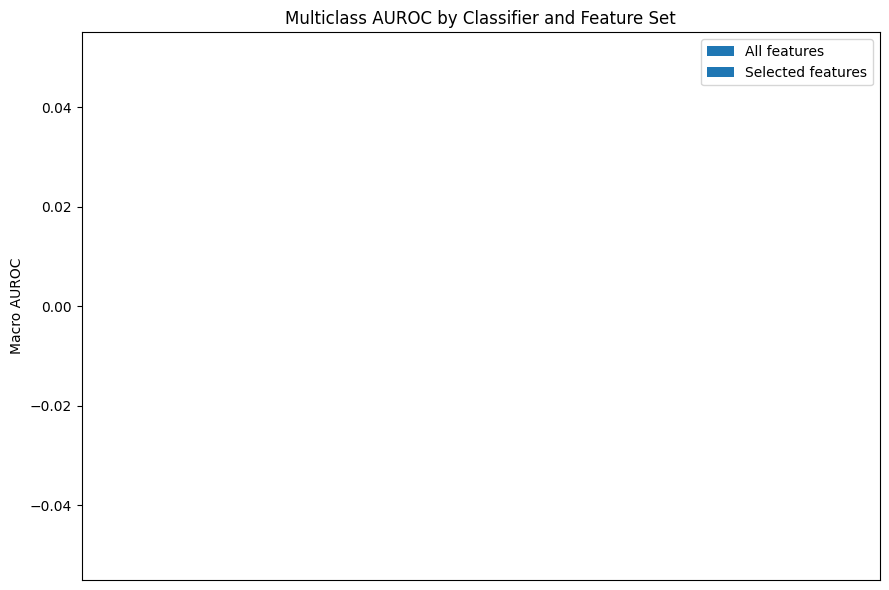

In [21]:

from sklearn.preprocessing import LabelEncoder, label_binarize


# 2. Classifiers to compare
classifiers = {
    "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000, random_state=42),
    "SVC": SVC(probability=True, random_state=42)
}

le = LabelEncoder()
le.fit(y_train)  # fit on train
y_train_int = le.transform(y_train)
y_test_int = le.transform(y_test)
all_classes = le.classes_

# Binarized labels for ROC/AUC (for all classifiers except XGBoost)
y_train_bin = label_binarize(y_train, classes=all_classes)
y_test_bin = label_binarize(y_test, classes=all_classes)

auroc_dict_all = {}
auroc_dict_sel = {}

for feature_set_name, (Xtr, Xte) in {
    "All features": (X_train, X_test),
    "Selected features": (X_train_sel, X_test_sel)
}.items():
    print(f"\n--- Using {feature_set_name} ---")
    for name, clf in classifiers.items():
        print(f"\nTraining {name}...")
        if name == "XGBoost":
            clf.fit(Xtr, y_train_int)
            y_proba = clf.predict_proba(Xte)
            auc = roc_auc_score(
                label_binarize(y_test_int, classes=range(len(all_classes))),
                y_proba, average="macro", multi_class="ovr"
            )
            y_pred = le.inverse_transform(clf.predict(Xte))  # Convert to strings!
        else:
            clf.fit(Xtr, y_train)
            y_proba = clf.predict_proba(Xte)
            auc = roc_auc_score(
                y_test_bin, y_proba, average="macro", multi_class="ovr"
            )
            y_pred = clf.predict(Xte)
        # --------- Make sure y_pred and y_test are strings! --------------
        if name == "XGBoost":
            y_pred_str = y_pred  # Already string after inverse_transform
            y_test_str = y_test  # y_test is string
        else:
            y_pred_str = y_pred
            y_test_str = y_test
        print("Classification report:")
        print(classification_report(y_test_str, y_pred_str, labels=all_classes))
        cm = confusion_matrix(y_test_str, y_pred_str, labels=all_classes)
        plt.figure(figsize=(7,6))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_classes, yticklabels=all_classes, cmap="Blues")
        plt.title(f"{name} Confusion Matrix ({feature_set_name})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()


# 4. Plot AUROC comparison
bar_width = 0.35
models = list(auroc_dict_all.keys())
x = np.arange(len(models))

plt.figure(figsize=(9,6))
plt.bar(x-bar_width/2, [auroc_dict_all[m] for m in models], bar_width, label='All features')
plt.bar(x+bar_width/2, [auroc_dict_sel[m] for m in models], bar_width, label='Selected features')
plt.xticks(x, models, rotation=20)
plt.ylabel("Macro AUROC")
plt.title("Multiclass AUROC by Classifier and Feature Set")
plt.legend()
plt.tight_layout()
plt.show()

RandomForest AUROC: 0.9063350283296904


d:\projects\UKY_Cheng\.venv\lib\site-packages\xgboost\training.py:183: UserWarning: [03:26:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUROC: 0.9081195898089207
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9174
[LightGBM] [Info] Number of data points in the train set: 1803, number of used features: 169
[LightGBM] [Info] Start training from score -2.184001
[LightGBM] [Info] Start training from score -1.095290
[LightGBM] [Info] Start training from score -1.602804
[LightGBM] [Info] Start training from score -1.806848
[LightGBM] [Info] Start training from score -1.674161
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LightGBM AUROC: 0.9096260551347004


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression AUROC: 0.8660967676014686
SVC AUROC: 0.8465064439158899


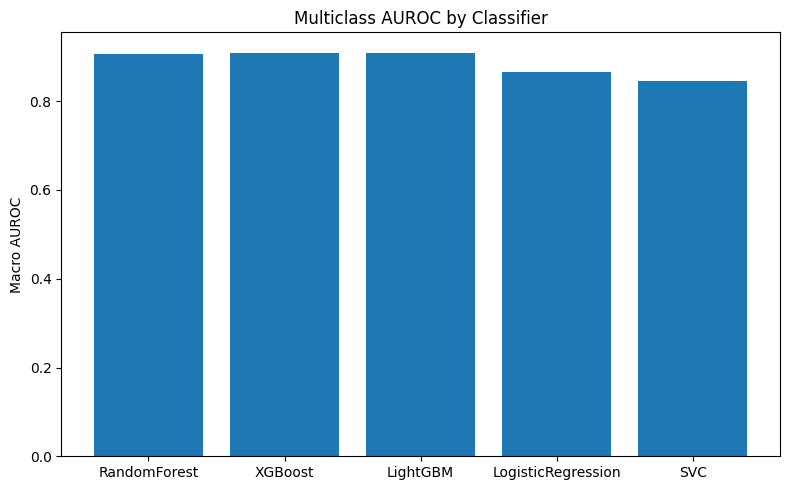


RandomForest classification report:
              precision    recall  f1-score   support

          A1       0.86      0.53      0.65       283
          A2       0.70      0.85      0.77       634
          B1       0.73      0.60      0.66       505
          B2       0.38      0.67      0.49       186
          B3       0.58      0.47      0.52       362

    accuracy                           0.65      1970
   macro avg       0.65      0.62      0.62      1970
weighted avg       0.68      0.65      0.65      1970



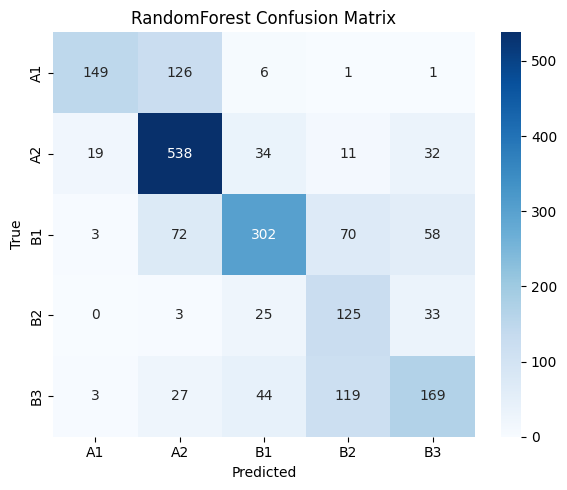


XGBoost classification report:


ValueError: Mix of label input types (string and number)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

# Label encoding for all models
le = LabelEncoder()
le.fit(y_train)
all_classes = le.classes_
n_classes = len(all_classes)

# For scikit-learn classifiers
y_train_bin = label_binarize(y_train, classes=all_classes)
y_test_bin = label_binarize(y_test, classes=all_classes)

# For XGBoost
y_train_int = le.transform(y_train)
y_test_int = le.transform(y_test)
y_test_bin_xgb = label_binarize(y_test_int, classes=range(n_classes))

auroc_results = {}

### ---- RANDOM FOREST ----
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)
rf_auc = roc_auc_score(y_test_bin, rf_probs, average="macro", multi_class="ovr")
auroc_results['RandomForest'] = rf_auc
print("RandomForest AUROC:", rf_auc)

### ---- XGBOOST ----
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train_int)
xgb_probs = xgb.predict_proba(X_test)
xgb_auc = roc_auc_score(y_test_bin_xgb, xgb_probs, average="macro", multi_class="ovr")
auroc_results['XGBoost'] = xgb_auc
print("XGBoost AUROC:", xgb_auc)

### ---- LIGHTGBM ----
lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)
lgbm_probs = lgbm.predict_proba(X_test)
lgbm_auc = roc_auc_score(y_test_bin, lgbm_probs, average="macro", multi_class="ovr")
auroc_results['LightGBM'] = lgbm_auc
print("LightGBM AUROC:", lgbm_auc)

### ---- LOGISTIC REGRESSION ----
lr = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_probs = lr.predict_proba(X_test)
lr_auc = roc_auc_score(y_test_bin, lr_probs, average="macro", multi_class="ovr")
auroc_results['LogisticRegression'] = lr_auc
print("LogisticRegression AUROC:", lr_auc)

### ---- SVC (Support Vector Classifier) ----
svc = SVC(probability=True, random_state=42)
svc.fit(X_train, y_train)
svc_probs = svc.predict_proba(X_test)
svc_auc = roc_auc_score(y_test_bin, svc_probs, average="macro", multi_class="ovr")
auroc_results['SVC'] = svc_auc
print("SVC AUROC:", svc_auc)

# ---- Plot results ----
plt.figure(figsize=(8, 5))
plt.bar(auroc_results.keys(), auroc_results.values())
plt.ylabel("Macro AUROC")
plt.title("Multiclass AUROC by Classifier")
plt.tight_layout()
plt.show()

# ---- Optionally: Print classification report for each ----
for model_name, probs, model in [
    ("RandomForest", rf_probs, rf),
    ("XGBoost", xgb_probs, xgb),
    ("LightGBM", lgbm_probs, lgbm),
    ("LogisticRegression", lr_probs, lr),
    ("SVC", svc_probs, svc),
]:
    print(f"\n{model_name} classification report:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, labels=all_classes))
    cm = confusion_matrix(y_test, y_pred, labels=all_classes)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_classes, yticklabels=all_classes, cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# Fresh model

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, brier_score_loss
)
from sklearn.calibration import calibration_curve
import shap


### Step 1: Data Preparation, 

### Step 2: Feature Engineering

### Step 3: Training/Test Split



In [6]:
# 1. Identify features
non_feature_cols = [
    "chrom", "start", "end", "subcompartment", "score", "strand",
    "thickStart", "thickEnd", "itemRgb", "chrom_num"
]
feature_cols = [col for col in subcompartments.columns if col not in non_feature_cols]

# 2. Split train/test by chromosome (even: train, odd: test)
train_chroms = [i for i in range(2, 24, 2)]
test_chroms = [i for i in range(1, 24, 2)]

train = subcompartments[subcompartments["chrom_num"].isin(train_chroms)].copy()
test = subcompartments[subcompartments["chrom_num"].isin(test_chroms)].copy()

print("Training bins:", train.shape)
print("Testing bins:", test.shape)

# 3. Prepare X and y
X_train = train[feature_cols].values
X_test = test[feature_cols].values

# Merge B4 into B3 (if present)
y_train = train["subcompartment"].replace({"B4": "B3"}).values
y_test = test["subcompartment"].replace({"B4": "B3"}).values

# Encode labels as integers for scikit-learn
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
class_names = label_encoder.classes_


Training bins: (1803, 180)
Testing bins: (1970, 180)


### Step 4: Random Forest Model (with Class Balancing)

1) Train a Random Forest classifier (RandomForestClassifier) with:

class_weight="balanced"

Sufficiently large n_estimators (e.g., 200)

Moderate max_depth (e.g., 10–20)

2) Hyperparameter tuning via GridSearchCV for optimal max_depth and min_samples_leaf.

3) Train on training bins (even chromosomes).



In [7]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

rf = RandomForestClassifier(random_state=42, class_weight="balanced")
cv = GridSearchCV(rf, param_grid, cv=3, n_jobs=-1, scoring="accuracy")
cv.fit(X_train, y_train_enc)

print("Best parameters:", cv.best_params_)

rf_best = cv.best_estimator_


Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 200}


In [8]:
y_pred_enc = rf_best.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_enc)
y_proba = rf_best.predict_proba(X_test)  # shape: [n_samples, n_classes]


              precision    recall  f1-score   support

          A1       0.86      0.53      0.65       283
          A2       0.70      0.85      0.77       634
          B1       0.73      0.60      0.66       505
          B2       0.38      0.67      0.49       186
          B3       0.58      0.47      0.52       362

    accuracy                           0.65      1970
   macro avg       0.65      0.62      0.62      1970
weighted avg       0.68      0.65      0.65      1970



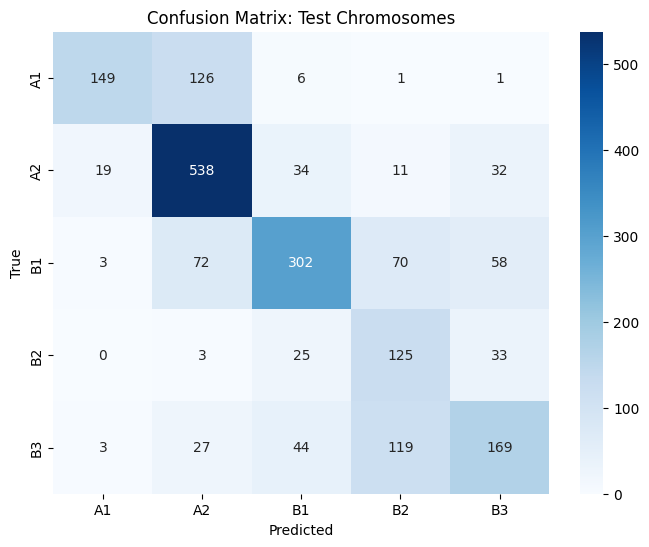

In [9]:
print(classification_report(y_test_enc, y_pred_enc, target_names=class_names))

cm = confusion_matrix(y_test_enc, y_pred_enc)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix: Test Chromosomes")
plt.show()


In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix

labels = ["A1", "A2", "B1", "B2", "B3"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Per-class accuracy: diagonal / row sums
per_class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
print("Per-class accuracy:", dict(zip(labels, per_class_accuracy)))


Per-class accuracy: {'A1': np.float64(0.5265017667844523), 'A2': np.float64(0.8485804416403786), 'B1': np.float64(0.598019801980198), 'B2': np.float64(0.6720430107526881), 'B3': np.float64(0.46685082872928174)}


In [10]:
def top_n_accuracy(y_true, y_proba, n=2):
    top_n = np.argsort(y_proba, axis=1)[:, -n:]  # indices of top-n classes
    matches = [y in top for y, top in zip(y_true, top_n)]
    return np.mean(matches)

print(f"Top-1 (accuracy): {top_n_accuracy(y_test_enc, y_proba, n=1):.3f}")
print(f"Top-2 accuracy: {top_n_accuracy(y_test_enc, y_proba, n=2):.3f}")
print(f"Top-3 accuracy: {top_n_accuracy(y_test_enc, y_proba, n=3):.3f}")


Top-1 (accuracy): 0.651
Top-2 accuracy: 0.876
Top-3 accuracy: 0.963


In [10]:
# One-vs-rest (macro-average)
try:
    auc = roc_auc_score(
        pd.get_dummies(y_test_enc, columns=class_names),  # shape: n x n_classes
        y_proba,
        multi_class="ovr",
        average="macro"
    )
    print(f"Multiclass AUROC (macro, ovr): {auc:.3f}")
except Exception as e:
    print("AUROC calculation failed:", e)


Multiclass AUROC (macro, ovr): 0.906


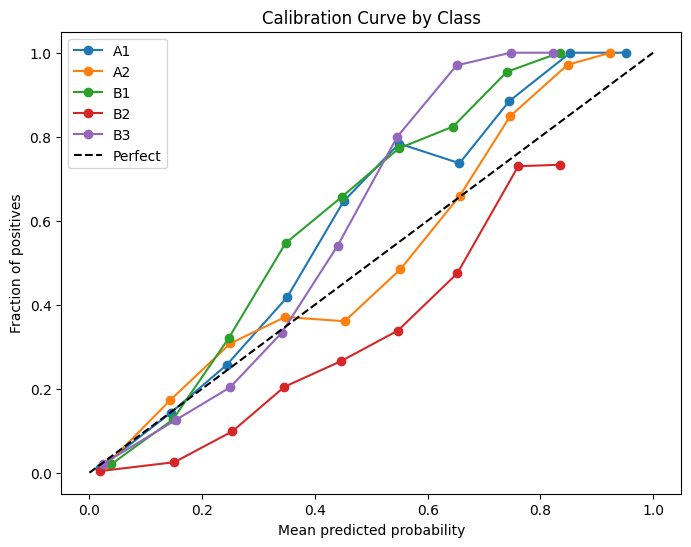

In [11]:
plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    prob_true, prob_pred = calibration_curve((y_test_enc == i), y_proba[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=class_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve by Class')
plt.legend()
plt.show()


In [12]:
brier_scores = []
for i, class_name in enumerate(class_names):
    score = brier_score_loss((y_test_enc == i), y_proba[:, i])
    brier_scores.append((class_name, score))
print("Brier scores by class:", brier_scores)


Brier scores by class: [('A1', 0.05899018589012221), ('A2', 0.11217392120803424), ('B1', 0.12134506501769042), ('B2', 0.0718785041258957), ('B3', 0.1033717562830694)]


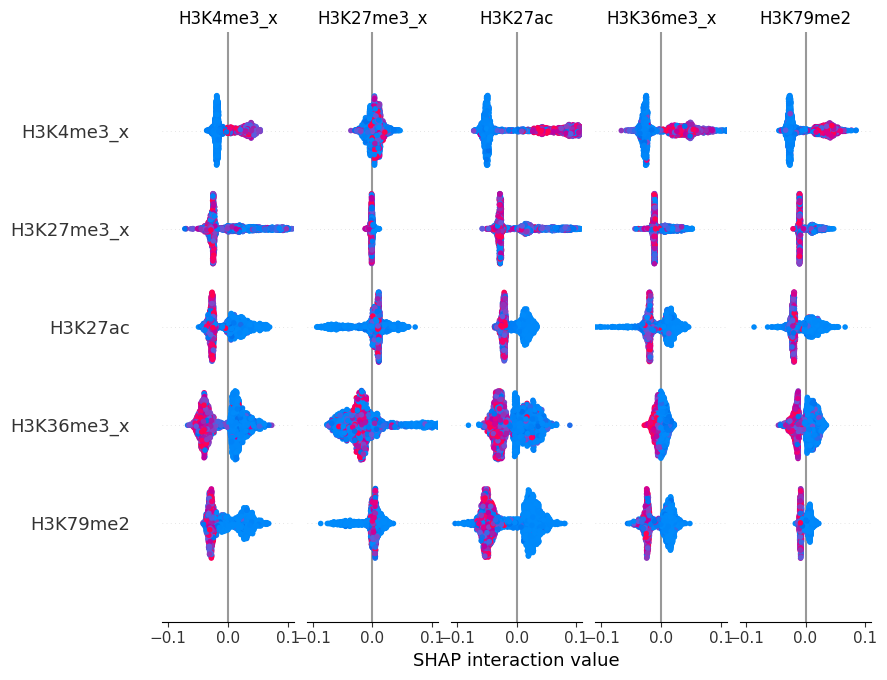


Top features for class A1:


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [35]:
import shap

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# Overall summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, class_names=class_names)

# Per-class SHAP summary
for i, class_name in enumerate(class_names):
    print(f"\nTop features for class {class_name}:")
    shap.summary_plot(shap_values[i], X_test, feature_names=feature_cols, class_names=class_names)


### Step 5: Probability Calibration

1) Wrap the trained RF model with CalibratedClassifierCV (method='isotonic', cv=3).

2) Fit the calibrator on the training set.

3) Obtain calibrated class probabilities for test bins (odd chromosomes).

In [13]:
from sklearn.calibration import CalibratedClassifierCV

# Wrap and fit on train set (RF already fit)
calibrator = CalibratedClassifierCV(estimator=rf_best, method='isotonic', cv=3)
calibrator.fit(X_train, y_train_enc)

# Predict probabilities on test set
y_proba_cal = calibrator.predict_proba(X_test)
y_pred_cal = calibrator.predict(X_test)  # Encoded labels
y_pred_cal_label = label_encoder.inverse_transform(y_pred_cal)


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, brier_score_loss

# Accuracy and classification report
print(classification_report(y_test_enc, y_pred_cal, target_names=class_names))

# Top-N accuracy
import numpy as np
def top_n_accuracy(y_true, y_proba, n=2):
    top_n = np.argsort(y_proba, axis=1)[:, -n:]
    matches = [y in top for y, top in zip(y_true, top_n)]
    return np.mean(matches)
print(f"Top-1 (accuracy): {top_n_accuracy(y_test_enc, y_proba_cal, n=1):.3f}")
print(f"Top-2 accuracy: {top_n_accuracy(y_test_enc, y_proba_cal, n=2):.3f}")
print(f"Top-3 accuracy: {top_n_accuracy(y_test_enc, y_proba_cal, n=3):.3f}")

# Multiclass AUROC (macro, ovr)
auc = roc_auc_score(
    np.eye(len(class_names))[y_test_enc],
    y_proba_cal,
    multi_class="ovr",
    average="macro"
)
print(f"Multiclass AUROC (macro, ovr): {auc:.3f}")

# Brier scores
brier_scores = []
for i, class_name in enumerate(class_names):
    score = brier_score_loss((y_test_enc == i), y_proba_cal[:, i])
    brier_scores.append((class_name, score))
print("Brier scores by class:", brier_scores)


              precision    recall  f1-score   support

          A1       0.87      0.49      0.63       283
          A2       0.70      0.84      0.76       634
          B1       0.73      0.62      0.67       505
          B2       0.44      0.64      0.52       186
          B3       0.54      0.52      0.53       362

    accuracy                           0.66      1970
   macro avg       0.66      0.62      0.62      1970
weighted avg       0.68      0.66      0.65      1970

Top-1 (accuracy): 0.655
Top-2 accuracy: 0.879
Top-3 accuracy: 0.964
Multiclass AUROC (macro, ovr): 0.905
Brier scores by class: [('A1', 0.06023113862286325), ('A2', 0.1127020607954831), ('B1', 0.11304823408657184), ('B2', 0.07146792497281908), ('B3', 0.10177103228844105)]


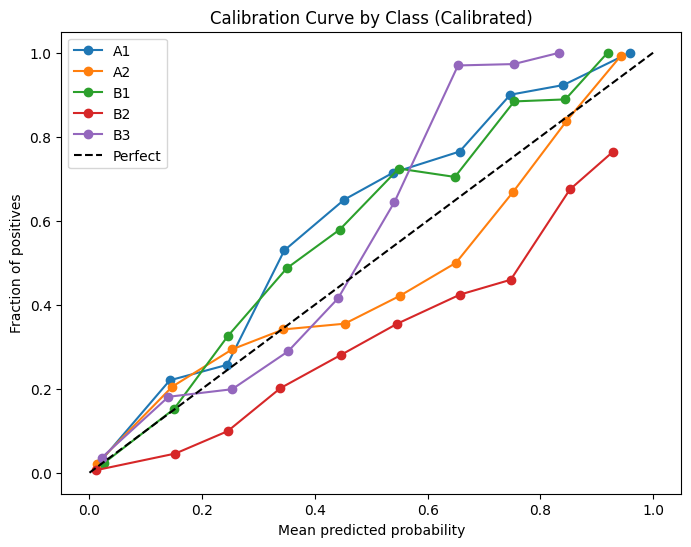

In [15]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    prob_true, prob_pred = calibration_curve((y_test_enc == i), y_proba_cal[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=class_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve by Class (Calibrated)')
plt.legend()
plt.show()


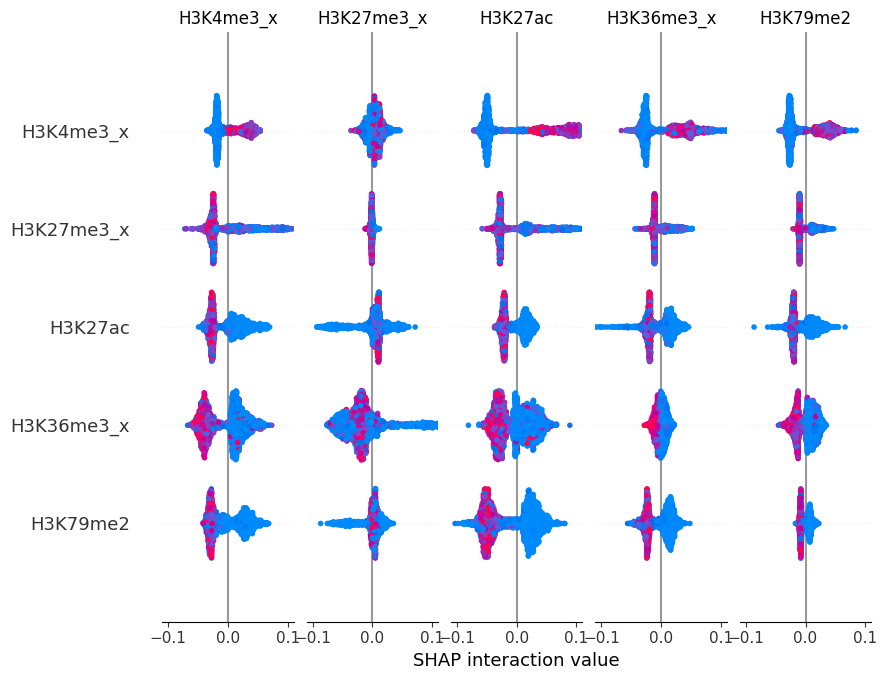

In [41]:
import shap

explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, class_names=class_names)


### Step 7: HMM Smoothing with Empirical Block Size Constraint

1. From the training set true subcompartment labels (not predictions!), estimate the average block length (number of consecutive bins) for each class.

- For each class:\
    `mean_block_size = mean(lengths of consecutive runs of that class across genome)`

2. Set the HMM transition matrix for class i:

- Diagonal: `p_stay[i] = 1 - 1/mean_block_size[i]`

- Off-diagonal: remaining probability distributed equally among other classes.

3. Fit a MultinomialHMM (hmmlearn) using the RF’s calibrated probability for each bin as the emission probability.

- Use `log_prob = np.log(y_proba_cal + 1e-8)` to avoid zero probabilities.

- Use Viterbi decoding to obtain the most probable subcompartment sequence along the genome.

4. Map the predicted integer state sequence back to class labels.



In [16]:
def compute_block_lengths(labels, class_names):
    block_lengths = {c: [] for c in class_names}
    prev = labels[0]
    count = 1
    for l in labels[1:]:
        if l == prev:
            count += 1
        else:
            block_lengths[prev].append(count)
            prev = l
            count = 1
    block_lengths[prev].append(count)
    mean_lengths = {k: np.mean(v) for k, v in block_lengths.items()}
    return mean_lengths

train_labels = label_encoder.inverse_transform(y_train_enc)
block_sizes = compute_block_lengths(train_labels, class_names)
print("Empirical block sizes:", block_sizes)


Empirical block sizes: {'A1': np.float64(1.0797872340425532), 'A2': np.float64(1.0134453781512605), 'B1': np.float64(1.0196629213483146), 'B2': np.float64(1.0922509225092252), 'B3': np.float64(1.0180722891566265)}


In [17]:
import numpy as np

n_classes = len(class_names)
transmat = np.zeros((n_classes, n_classes))
for i, cname in enumerate(class_names):
    L = block_sizes[cname]
    p_stay = 1 - 1/L
    transmat[i, i] = p_stay
    for j in range(n_classes):
        if i != j:
            transmat[i, j] = (1 - p_stay) / (n_classes - 1)


In [18]:
import numpy as np

def viterbi_log(emission_logp, transmat, startprob):
    """
    Viterbi decoding for sequence labeling with log-probability emissions.
    emission_logp: shape (n_bins, n_classes), log probabilities per bin per class.
    transmat: shape (n_classes, n_classes), transition probabilities.
    startprob: shape (n_classes,), initial class probabilities.
    Returns: most likely class index per bin (length n_bins)
    """
    n_bins, n_classes = emission_logp.shape
    # Log-transform everything for stability
    log_transmat = np.log(transmat + 1e-16)
    log_startprob = np.log(startprob + 1e-16)

    dp = np.full((n_bins, n_classes), -np.inf)
    ptr = np.zeros((n_bins, n_classes), dtype=int)

    # Initialization
    dp[0] = log_startprob + emission_logp[0]
    for t in range(1, n_bins):
        for j in range(n_classes):
            prob_options = dp[t-1] + log_transmat[:, j]
            ptr[t, j] = np.argmax(prob_options)
            dp[t, j] = np.max(prob_options) + emission_logp[t, j]
    # Backtrack
    states = np.zeros(n_bins, dtype=int)
    states[-1] = np.argmax(dp[-1])
    for t in reversed(range(1, n_bins)):
        states[t-1] = ptr[t, states[t]]
    return states

# Usage:
log_emissions = np.log(y_proba_cal + 1e-12)  # (n_bins, n_classes)
startprob = np.ones(n_classes) / n_classes
states = viterbi_log(log_emissions, transmat, startprob)
y_pred_hmm = [class_names[i] for i in states]


In [19]:
test['rf_pred'] = label_encoder.inverse_transform(y_pred_cal)
test['rf_prob_max'] = y_proba_cal.max(axis=1)
for i, class_name in enumerate(class_names):
    test[f'proba_{class_name}'] = y_proba_cal[:, i]
test['hmm_pred'] = y_pred_hmm
test['correct_rf'] = (test['rf_pred'] == test['subcompartment'])
test['correct_hmm'] = (test['hmm_pred'] == test['subcompartment'])

# Export as BED for IGV/UCSC
bed_cols = ['chrom', 'start', 'end', 'subcompartment', 'rf_pred', 'hmm_pred'] + [f'proba_{c}' for c in class_names]
#test[bed_cols].to_csv('subcompartment_predictions.bed', sep='\t', index=False)


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print("=== HMM-smoothed ===")
print(classification_report(test['subcompartment'], test['hmm_pred']))
print("Confusion Matrix (HMM):\n", confusion_matrix(test['subcompartment'], test['hmm_pred'], labels=class_names))


=== HMM-smoothed ===
              precision    recall  f1-score   support

          A1       0.87      0.66      0.75       283
          A2       0.78      0.84      0.80       634
          B1       0.73      0.66      0.70       505
          B2       0.46      0.60      0.52       186
          B3       0.56      0.61      0.58       338
          B4       0.00      0.00      0.00        24

    accuracy                           0.70      1970
   macro avg       0.56      0.56      0.56      1970
weighted avg       0.70      0.70      0.69      1970

Confusion Matrix (HMM):
 [[187  87   7   0   2]
 [ 21 530  43   4  36]
 [  6  43 335  44  77]
 [  0   1  26 111  48]
 [  0   1  47  83 207]]


d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\projects\UKY_Cheng\.venv\lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


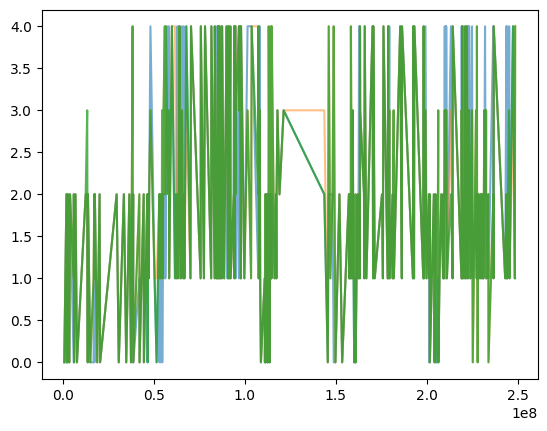

In [24]:
import matplotlib.pyplot as plt

# Example for one chromosome:
chrom = "chr1"
df_chr = test[test['chrom'] == chrom]

class_to_int = {name: i for i, name in enumerate(class_names)}

plt.plot(
    df_chr['start'],
    [class_to_int[l] for l in df_chr['subcompartment']],
    label="True", alpha=0.6)
plt.plot(
    df_chr['start'],
    [class_to_int[l] for l in df_chr['rf_pred']],
    label="RF", alpha=0.5)
plt.plot(
    df_chr['start'],
    [class_to_int[l] for l in df_chr['hmm_pred']],
    label="HMM", alpha=0.8)



In [22]:
import numpy as np

def get_block_sizes(labels):
    sizes = []
    last = labels[0]
    count = 1
    for l in labels[1:]:
        if l == last:
            count += 1
        else:
            sizes.append(count)
            last = l
            count = 1
    sizes.append(count)
    return sizes

for col in ['subcompartment', 'rf_pred', 'hmm_pred']:
    sizes = get_block_sizes(test[col].tolist())
    print(f"Median block size ({col}):", np.median(sizes))
    print(f"Mean block size ({col}):", np.mean(sizes))


Median block size (subcompartment): 1.0
Mean block size (subcompartment): 1.0352075669994745
Median block size (rf_pred): 1.0
Mean block size (rf_pred): 1.214549938347719
Median block size (hmm_pred): 1.0
Mean block size (hmm_pred): 1.012332990750257


In [25]:
def compute_block_sizes_per_label(labels):
    """Returns a dict: label -> list of block sizes."""
    block_sizes = {}
    if len(labels) == 0:
        return block_sizes
    last_label = labels[0]
    count = 1
    for l in labels[1:]:
        if l == last_label:
            count += 1
        else:
            block_sizes.setdefault(last_label, []).append(count)
            last_label = l
            count = 1
    block_sizes.setdefault(last_label, []).append(count)
    return block_sizes

gt_blocks = compute_block_sizes_per_label(test['subcompartment'].tolist())
rf_blocks = compute_block_sizes_per_label(test['rf_pred'].tolist())
hmm_blocks = compute_block_sizes_per_label(test['hmm_pred'].tolist())

import numpy as np

print("Subcompartment | GT median | RF median | HMM median | GT mean | RF mean | HMM mean")
for c in class_names:
    gt = gt_blocks.get(c, [])
    rf = rf_blocks.get(c, [])
    hmm = hmm_blocks.get(c, [])
    print(f"{c:14} | "
          f"{np.median(gt) if gt else 0:8.2f} | "
          f"{np.median(rf) if rf else 0:8.2f} | "
          f"{np.median(hmm) if hmm else 0:8.2f} | "
          f"{np.mean(gt) if gt else 0:7.2f} | "
          f"{np.mean(rf) if rf else 0:7.2f} | "
          f"{np.mean(hmm) if hmm else 0:7.2f}")


Subcompartment | GT median | RF median | HMM median | GT mean | RF mean | HMM mean
A1             |     1.00 |     1.00 |     1.00 |    1.05 |    1.04 |    1.01
A2             |     1.00 |     1.00 |     1.00 |    1.01 |    1.25 |    1.00
B1             |     1.00 |     1.00 |     1.00 |    1.02 |    1.16 |    1.00
B2             |     1.00 |     1.00 |     1.00 |    1.14 |    1.44 |    1.10
B3             |     1.00 |     1.00 |     1.00 |    1.04 |    1.15 |    1.00


Compartment Check

comp_gt: Median block size = 1.00, Mean = 1.39, #Blocks = 1419
comp_rf: Median block size = 1.00, Mean = 1.46, #Blocks = 1351
comp_hmm: Median block size = 1.00, Mean = 1.35, #Blocks = 1455
Compartment Accuracy (RF): 0.9010152284263959
Compartment Accuracy (HMM): 0.915736040609137
Compartment Jaccard (RF): 0.9010152284263959
Compartment Jaccard (HMM): 0.915736040609137


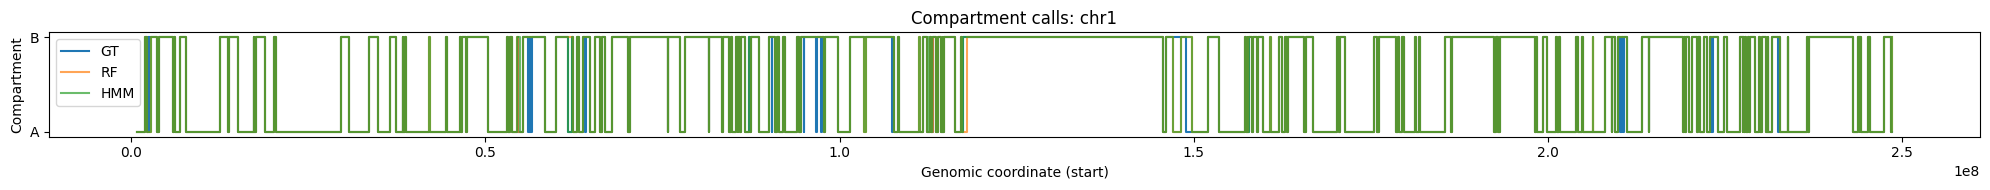

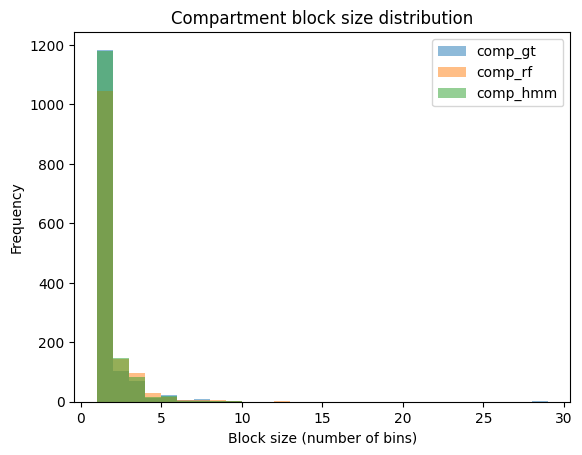

In [27]:
def subc_to_compartment(labels):
    # Assumes labels like 'A1', 'A2', 'B1', etc.
    return ['A' if l.startswith('A') else 'B' for l in labels]

test['comp_gt'] = subc_to_compartment(test['subcompartment'])
test['comp_rf'] = subc_to_compartment(test['rf_pred'])
test['comp_hmm'] = subc_to_compartment(test['hmm_pred'])

def get_block_sizes(labels):
    sizes = []
    last = labels[0]
    count = 1
    for l in labels[1:]:
        if l == last:
            count += 1
        else:
            sizes.append(count)
            last = l
            count = 1
    sizes.append(count)
    return sizes

for ctrack in ['comp_gt', 'comp_rf', 'comp_hmm']:
    sizes = get_block_sizes(test[ctrack].tolist())
    print(f"{ctrack}: Median block size = {np.median(sizes):.2f}, Mean = {np.mean(sizes):.2f}, #Blocks = {len(sizes)}")


from sklearn.metrics import accuracy_score

print("Compartment Accuracy (RF):", accuracy_score(test['comp_gt'], test['comp_rf']))
print("Compartment Accuracy (HMM):", accuracy_score(test['comp_gt'], test['comp_hmm']))

def jaccard_index(a, b):
    a = np.array(a)
    b = np.array(b)
    return (a == b).sum() / len(a)

print("Compartment Jaccard (RF):", jaccard_index(test['comp_gt'], test['comp_rf']))
print("Compartment Jaccard (HMM):", jaccard_index(test['comp_gt'], test['comp_hmm']))

import matplotlib.pyplot as plt

chrom = "chr1"
df_chr = test[test['chrom'] == chrom].copy()

# For plotting, encode 'A' as 0, 'B' as 1
comp_map = {'A': 0, 'B': 1}

plt.figure(figsize=(20, 2))
plt.plot(df_chr['start'], [comp_map[l] for l in df_chr['comp_gt']], label="GT", drawstyle="steps-post")
plt.plot(df_chr['start'], [comp_map[l] for l in df_chr['comp_rf']], label="RF", alpha=0.7, drawstyle="steps-post")
plt.plot(df_chr['start'], [comp_map[l] for l in df_chr['comp_hmm']], label="HMM", alpha=0.7, drawstyle="steps-post")
plt.yticks([0, 1], ['A', 'B'])
plt.xlabel("Genomic coordinate (start)")
plt.ylabel("Compartment")
plt.title(f"Compartment calls: {chrom}")
plt.legend()
plt.tight_layout()
plt.show()

for ctrack in ['comp_gt', 'comp_rf', 'comp_hmm']:
    sizes = get_block_sizes(test[ctrack].tolist())
    plt.hist(sizes, bins=range(1, 30), alpha=0.5, label=ctrack)
plt.xlabel("Block size (number of bins)")
plt.ylabel("Frequency")
plt.title("Compartment block size distribution")
plt.legend()
plt.show()


In [23]:
test['correct_rf'] = (test['rf_pred'] == test['subcompartment'])
test['correct_hmm'] = (test['hmm_pred'] == test['subcompartment'])

# Find bins where HMM fixed an RF error:
fixed = (~test['correct_rf']) & (test['correct_hmm'])
print("HMM fixed RF errors in", fixed.sum(), "bins")


HMM fixed RF errors in 134 bins


In [ ]:
bed_cols = ['chrom', 'start', 'end', 'subcompartment', 'rf_pred', 'hmm_pred']
#test[bed_cols].to_csv("subcompartments_hmm_rf.bed", sep="\t", index=False)
